# Synthetic results

This notebook reports the completed primary DVFM-only synthetic experiment from `results/synthetic/`. It requires the run success marker and reads the raw prediction, latent-diagnostic, and run-manifest artifacts directly.

The four figures address four claims: individual frailty recovery, joint-survival recovery, Kendall's $	au$ calibration, and predictive benefit over the $z=0$ ablation. `synthetic_frailty_recovery.pdf` omits $	au=0$ because subject-level frailty recovery is undefined when the DGP has no shared-frailty signal. `synthetic_joint_survival_gain.pdf` reports the paired z0-minus-z1 joint-survival ISE improvement. `synthetic_dependence_calibration.pdf` compares estimated conditional Kendall's $	au$ with its target for DVFM-z1; the dashed diagonal denotes perfect calibration, points below it indicate underestimation, and points above it indicate overestimation. It does not plot latent-$z$ values. `synthetic_event_prediction_gain.pdf` reports the paired z0-minus-z1 Oracle IBS improvement. Values above zero in the two gain figures favor the shared-latent model.

In [23]:
from pathlib import Path
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, FuncFormatter, MultipleLocator

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}",
    "savefig.bbox": "tight",
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "xtick.minor.size": 0,
    "ytick.minor.size": 0,
})

ROOT = Path.cwd()
if not (ROOT / "configs" / "synthetic.yaml").exists():
    ROOT = ROOT.parent
RESULT_DIR = ROOT / "results" / "synthetic"
FIGURE_DIR = ROOT / "paper" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
def _primary_dvfm_rows(frame):
    out = frame[frame["model"].astype(str).str.lower().eq("dvfm")].copy()
    out = out[out["is_primary_checkpoint"].astype(str).str.lower().eq("true")]
    if "prediction_mode" in out:
        out = out[out["prediction_mode"].astype(str).str.lower().eq("aggregate_posterior")]
    return out

raw_path = RESULT_DIR / "results_raw.csv"
diagnostic_path = RESULT_DIR / "dvfm_diagnostics.csv"
manifest_path = RESULT_DIR / "run_manifest.csv"
required = [RESULT_DIR / "_SUCCESS", raw_path, diagnostic_path, manifest_path]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Synthetic run is incomplete; missing: " + ", ".join(missing))

manifest = pd.read_csv(manifest_path)
failures = manifest[~manifest["status"].eq("success")]
if not failures.empty:
    raise RuntimeError(f"Synthetic run contains {len(failures)} failed fits")
raw = _primary_dvfm_rows(pd.read_csv(raw_path))
diagnostics = _primary_dvfm_rows(pd.read_csv(diagnostic_path))
diagnostics = diagnostics[pd.to_numeric(diagnostics["latent_dim"], errors="coerce").eq(1)].copy()
if len(manifest) != 240 or len(raw) != 240 or len(diagnostics) != 360:
    raise RuntimeError(
        f"Unexpected artifact sizes: manifest={len(manifest)}, raw={len(raw)}, "
        f"z1 diagnostics={len(diagnostics)}"
    )
print(
    "COMPLETED SYNTHETIC RESULTS",
    f"| fits={len(manifest):,}, primary aggregate-posterior rows={len(raw):,}, z1 diagnostics={len(diagnostics):,}",
)

COMPLETED SYNTHETIC RESULTS | fits=240, primary aggregate-posterior rows=240, z1 diagnostics=360


Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_frailty_recovery.pdf
Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_joint_survival_gain.pdf
Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_dependence_calibration.pdf
Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_event_prediction_gain.pdf


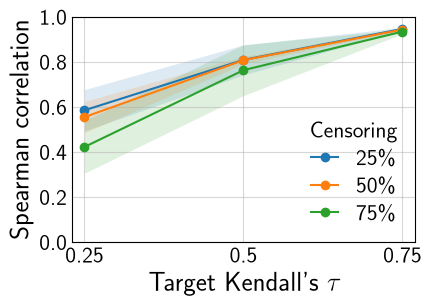

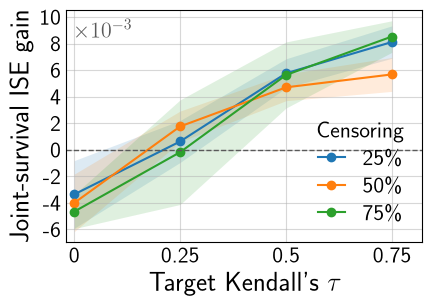

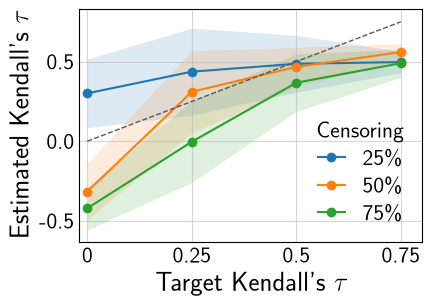

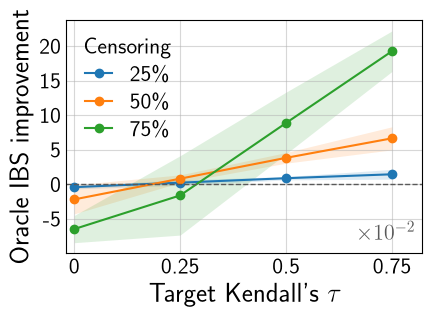

In [25]:
def mean_band(frame, groups, metric, sigma_level=1.0):
    out = frame.groupby(groups)[metric].agg(["mean", "std", "count"]).reset_index()
    out["error"] = sigma_level * out["std"].fillna(0)
    return out

z1 = raw[pd.to_numeric(raw["latent_dim"], errors="coerce").eq(1)].copy()
frailty_all = diagnostics[diagnostics["subgroup"].eq("all")].copy()
frailty_summary = mean_band(frailty_all, ["target_kendall_tau", "target_censoring_rate"], "frailty_spearman")
frailty_summary = frailty_summary[frailty_summary["target_kendall_tau"].gt(0)].copy()
tau_summary = mean_band(z1, ["target_kendall_tau", "target_censoring_rate"], "learned_conditional_kendall_tau")
joint_wide = raw.pivot_table(index=["repeat", "target_kendall_tau", "target_censoring_rate"], columns="latent_dim", values="oracle_joint_survival_ise").reset_index()
joint_wide["joint_ise_gain"] = joint_wide[0] - joint_wide[1]
joint_summary = mean_band(joint_wide, ["target_kendall_tau", "target_censoring_rate"], "joint_ise_gain")

ibs_wide = raw.pivot_table(index=["repeat", "target_kendall_tau", "target_censoring_rate"], columns="latent_dim", values="oracle_ibs").reset_index()
ibs_wide["oracle_ibs_gain"] = ibs_wide[0] - ibs_wide[1]
gain_summary = mean_band(ibs_wide, ["target_kendall_tau", "target_censoring_rate"], "oracle_ibs_gain")

# Sized so that at 0.49\linewidth in the paper the panels are reproduced at
# roughly 1:1.6, leaving the 16 pt figure type near the 10 pt body type.
PANEL_FIGSIZE = (4.2, 2.95)
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = dict(zip((0.25, 0.50, 0.75), default_colors[:3]))
tau_ticks = np.array([0.0, 0.25, 0.5, 0.75])
tau_tick_labels = ["0", "0.25", "0.5", "0.75"]
frailty_taus = np.sort(frailty_summary["target_kendall_tau"].unique())


def draw_bands(ax, summary):
    for censoring, part in summary.groupby("target_censoring_rate"):
        part = part.sort_values("target_kendall_tau")
        x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "error"))
        ax.fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
        ax.plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")


def new_panel():
    fig, ax = plt.subplots(figsize=PANEL_FIGSIZE, constrained_layout=True)
    return fig, ax


def add_legend(ax, loc="lower right", ncol=1):
    ax.legend(title="Censoring", loc=loc, ncol=ncol, frameon=False,
              columnspacing=0.8, handlelength=1.2, labelspacing=0.3,
              borderaxespad=0.4)


def save_panel(fig, name):
    out = FIGURE_DIR / name
    fig.savefig(out)
    print(f"Wrote {out}")
    return out


# A  Individual frailty recovery
fig_a, ax_a = new_panel()
draw_bands(ax_a, frailty_summary)
ax_a.set_xticks(frailty_taus, [f"{tau:g}" for tau in frailty_taus])
ax_a.set(xlabel=r"Target Kendall's $\tau$", ylabel="Spearman correlation", xlim=(0.23, 0.77), ylim=(0, 1))
ax_a.set_yticks(np.arange(0.0, 1.01, 0.2))
ax_a.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
add_legend(ax_a)
ax_a.grid(True, alpha=0.5)
save_panel(fig_a, "synthetic_frailty_recovery.pdf")

# B  Joint-survival gain from latent z
fig_b, ax_b = new_panel()
draw_bands(ax_b, joint_summary)
ax_b.axhline(0, color="0.35", linestyle="--", linewidth=1)
ax_b.set(xlabel=r"Target Kendall's $\tau$", ylabel="Joint-survival ISE gain", xlim=(-0.02, 0.82))
ax_b.set_xticks(tau_ticks, tau_tick_labels)
ax_b.yaxis.set_major_locator(MultipleLocator(0.002))
ax_b.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value * 1e3:.0f}"))
ax_b.text(0.02, 0.96, r"$\times 10^{-3}$", transform=ax_b.transAxes, va="top", color="0.35")
add_legend(ax_b)
ax_b.grid(True, alpha=0.5)
save_panel(fig_b, "synthetic_joint_survival_gain.pdf")

# C  Dependence calibration
fig_c, ax_c = new_panel()
draw_bands(ax_c, tau_summary)
tau_low = min(0.0, float((tau_summary["mean"] - tau_summary["error"]).min()))
tau_high = max(0.75, float((tau_summary["mean"] + tau_summary["error"]).max()))
tau_pad = 0.06 * (tau_high - tau_low)
ax_c.plot([0, 0.75], [0, 0.75], color="0.35", linestyle="--", linewidth=1)
ax_c.set(xlabel=r"Target Kendall's $\tau$", ylabel=r"Estimated Kendall's $\tau$", xlim=(-0.02, 0.80), ylim=(tau_low - tau_pad, tau_high + tau_pad))
ax_c.set_xticks(tau_ticks, tau_tick_labels)
ax_c.yaxis.set_major_locator(MultipleLocator(0.5))
ax_c.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
add_legend(ax_c)
ax_c.grid(True, alpha=0.5)
save_panel(fig_c, "synthetic_dependence_calibration.pdf")

# D  Event-prediction gain from latent z
fig_d, ax_d = new_panel()
draw_bands(ax_d, gain_summary)
ax_d.axhline(0, color="0.35", linestyle="--", linewidth=1)
ax_d.set(xlabel=r"Target Kendall's $\tau$", ylabel="Oracle IBS improvement", xlim=(-0.02, 0.82))
ax_d.set_xticks(tau_ticks, tau_tick_labels)
ax_d.yaxis.set_major_locator(MultipleLocator(0.05))
ax_d.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value * 1e2:.0f}"))
ax_d.text(0.98, 0.04, r"$\times 10^{-2}$", transform=ax_d.transAxes, ha="right", va="bottom", color="0.35")
add_legend(ax_d, loc="upper left")
ax_d.grid(True, alpha=0.5)
save_panel(fig_d, "synthetic_event_prediction_gain.pdf")

plt.show()

Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_frailty_recovery.pdf
Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_joint_survival_gain.pdf
Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_dependence_calibration.pdf
Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_event_prediction_gain.pdf


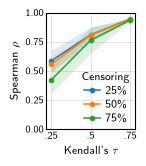

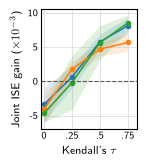

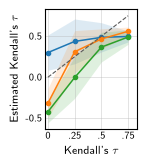

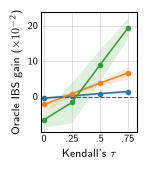

In [28]:
from matplotlib import ticker

# Generated at final size (0.24\linewidth = 1.32in), so fonts render 1:1.
PANEL_FIGSIZE = (1.35, 1.55)
plt.rcParams.update({
    "font.size": 8, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 8, "legend.title_fontsize": 8,
    "lines.markersize": 3.0, "lines.linewidth": 1.1,
    "xtick.major.pad": 2, "ytick.major.pad": 2,
})

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = dict(zip((0.25, 0.50, 0.75), default_colors[:3]))
tau_ticks = np.array([0.0, 0.25, 0.5, 0.75])
tau_tick_labels = ["0", ".25", ".5", ".75"]     # leading zeros dropped for width
frailty_taus = np.sort(frailty_summary["target_kendall_tau"].unique())


def draw_bands(ax, summary):
    for censoring, part in summary.groupby("target_censoring_rate"):
        part = part.sort_values("target_kendall_tau")
        x, mean, ci = (part[name].to_numpy(dtype=float)
                       for name in ("target_kendall_tau", "mean", "error"))
        ax.fill_between(x, mean - ci, mean + ci, color=colors[censoring],
                        alpha=0.15, linewidth=0)
        ax.plot(x, mean, marker="o", color=colors[censoring],
                label=rf"{100*censoring:.0f}\%")


def new_panel():
    fig, ax = plt.subplots(figsize=PANEL_FIGSIZE, constrained_layout=True)
    ax.set_xlabel(r"Kendall's $\tau$")
    ax.grid(True, alpha=0.5, linewidth=0.5)
    return fig, ax


def save_panel(fig, name):
    out = FIGURE_DIR / name
    fig.savefig(out)
    print(f"Wrote {out}")
    return out


# A  Individual frailty recovery -- the only panel carrying the legend
fig_a, ax_a = new_panel()
draw_bands(ax_a, frailty_summary)
ax_a.set_xticks(frailty_taus, [f"{t:g}".lstrip("0") for t in frailty_taus])
ax_a.set(ylabel=r"Spearman $\rho$", xlim=(0.22, 0.78), ylim=(0, 1))
ax_a.set_yticks(np.arange(0.0, 1.01, 0.25))
ax_a.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax_a.legend(title="Censoring", loc="lower right", frameon=False,
            handlelength=1.4, labelspacing=0.3, handletextpad=0.5,
            borderaxespad=0.3, borderpad=0.2)
save_panel(fig_a, "synthetic_frailty_recovery.pdf")

# B  Joint-survival gain from latent z
fig_b, ax_b = new_panel()
draw_bands(ax_b, joint_summary)
ax_b.axhline(0, color="0.35", linestyle="--", linewidth=0.8)
ax_b.set(ylabel=r"Joint ISE gain ($\times 10^{-3}$)", xlim=(-0.03, 0.83))
ax_b.set_xticks(tau_ticks, tau_tick_labels)
ax_b.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
ax_b.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v * 1e3:.0f}"))
save_panel(fig_b, "synthetic_joint_survival_gain.pdf")

# C  Dependence calibration
fig_c, ax_c = new_panel()
draw_bands(ax_c, tau_summary)
tau_low = min(0.0, float((tau_summary["mean"] - tau_summary["error"]).min()))
tau_high = max(0.75, float((tau_summary["mean"] + tau_summary["error"]).max()))
tau_pad = 0.06 * (tau_high - tau_low)
ax_c.plot([0, 0.75], [0, 0.75], color="0.35", linestyle="--", linewidth=0.8)
ax_c.set(ylabel=r"Estimated Kendall's $\tau$", xlim=(-0.03, 0.83),
         ylim=(tau_low - tau_pad, tau_high + tau_pad))
ax_c.set_xticks(tau_ticks, tau_tick_labels)
ax_c.yaxis.set_major_locator(MultipleLocator(0.5))
ax_c.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
save_panel(fig_c, "synthetic_dependence_calibration.pdf")

# D  Event-prediction gain from latent z
fig_d, ax_d = new_panel()
draw_bands(ax_d, gain_summary)
ax_d.axhline(0, color="0.35", linestyle="--", linewidth=0.8)
ax_d.set(ylabel=r"Oracle IBS gain ($\times 10^{-2}$)", xlim=(-0.03, 0.83))
ax_d.set_xticks(tau_ticks, tau_tick_labels)
ax_d.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
ax_d.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v * 1e2:.0f}"))
save_panel(fig_d, "synthetic_event_prediction_gain.pdf")

plt.show()